# Evaluación Parcial N°1 — Fundamentos de Deep Learning

**Asignatura:** DLY0100 — Deep Learning
**Institución:** Duoc UC
**Estudiante:** Nicolas (trabajo individual)
**Dataset:** CIFAR-10 (Universidad de Toronto)
**Framework:** TensorFlow 2.x / Keras
**Tipo de problema:** Clasificación multiclase de imágenes (10 categorías)

---

## Tabla de contenidos

1. **Introducción** — descripción del problema y objetivo del modelo
2. **Carga y preprocesamiento de datos**
   - 2.1 Importación de librerías
   - 2.2 Carga manual desde Google Drive (verificación de dominio del formato)
   - 2.3 Carga vía Keras (método principal)
   - 2.4 Verificación de equivalencia entre ambos métodos
   - 2.5 Visualización del dataset
   - 2.6 Preprocesamiento justificado
3. **Definición del modelo MLP base**
4. **Entrenamiento del modelo base e identificación de overfitting**
5. **Experimentos controlados — hiperparámetros**
   - 5.1 Learning rate
   - 5.2 Batch size
   - 5.3 Profundidad de la red (n° capas)
   - 5.4 Anchura de la red (n° unidades)
6. **Comparación de funciones**
   - 6.1 Activación (sigmoid, tanh, ReLU, LeakyReLU)
   - 6.2 Error/loss (crossentropy, MSE, KL)
   - 6.3 Salida (softmax vs sigmoid — y por qué importa)
7. **Comparación de optimizadores** (SGD, RMSprop, Adam, AdamW)
8. **Técnicas de optimización y regularización**
   - 8.1 BatchNormalization
   - 8.2 Dropout
   - 8.3 L2 regularization
   - 8.4 Data augmentation aplicable a MLP
   - 8.5 Modelo final combinando todas las técnicas
9. **Validación cruzada k-fold**
10. **Ensemble de modelos**
11. **Evaluación con métricas** (accuracy, precision, recall, F1, top-K)
12. **Análisis de errores y matriz de confusión**
13. **Comparación final de todas las configuraciones**
14. **Conclusiones y reflexiones**

---

## 1. Introducción y descripción del problema

### Contexto
**CIFAR-10** (Canadian Institute for Advanced Research, 10 classes) es uno de los datasets más utilizados como benchmark en visión por computador. Fue creado por Alex Krizhevsky, Vinod Nair y Geoffrey Hinton en la Universidad de Toronto.

**Composición:**
- **60.000 imágenes** a color de **32×32 píxeles** (3 canales RGB)
- **10 clases** mutuamente excluyentes (6.000 imágenes por clase)
- División oficial: 50.000 imágenes para entrenamiento + 10.000 para test

| ID | Clase EN | Clase ES |
|----|----------|----------|
| 0 | airplane | avión |
| 1 | automobile | automóvil |
| 2 | bird | pájaro |
| 3 | cat | gato |
| 4 | deer | ciervo |
| 5 | dog | perro |
| 6 | frog | rana |
| 7 | horse | caballo |
| 8 | ship | barco |
| 9 | truck | camión |

### Objetivo del trabajo
Implementar una **red neuronal artificial multicapa (MLP / Perceptrón Multicapa)** que aprenda a clasificar imágenes de CIFAR-10 en sus 10 categorías correspondientes.

### ¿Por qué un MLP y no una CNN?
La rúbrica especifica MLP. Aunque las **redes convolucionales (CNN)** son el estado del arte para imágenes (alcanzan ~95% en CIFAR-10), un MLP nos permite:

1. **Aplicar todos los fundamentos teóricos** de Deep Learning: perceptrón, perceptrón multicapa, funciones de activación, error y salida, retropropagación.
2. **Demostrar el impacto de cada decisión técnica** (arquitectura, hiperparámetros, regularización) en un problema acotado.
3. **Reflexionar sobre las limitaciones** de un MLP frente a problemas estructurados espacialmente — esto demuestra criterio técnico maduro.

**Expectativa de rendimiento:** un MLP bien implementado en CIFAR-10 alcanza ~50-58% de accuracy. Compararemos esto con lo que se podría lograr con CNN (~90%+) en las conclusiones.

## 2. Carga y preprocesamiento de datos

### 2.1 Importación de librerías

In [11]:
# Librerias estandar de Python
import os
import time
import pickle
import tarfile
from collections import defaultdict

# Librerias cientificas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Scikit-learn (metricas y K-fold)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, top_k_accuracy_score
)
from sklearn.model_selection import train_test_split, KFold

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

# Configuracion de visualizacion
plt.rcParams['figure.dpi'] = 100
sns.set_palette('viridis')

# Verificar entorno
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"GPU disponible:     {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Devices:            {[d.name for d in tf.config.list_physical_devices('GPU')]}")

TensorFlow version: 2.20.0
Keras version:      3.13.2
GPU disponible:     True
Devices:            ['/physical_device:GPU:0']


### 2.2 Carga manual desde los archivos originales (verificación de dominio)

Antes de usar el método "fácil" de Keras, demostramos dominio del formato del dataset cargando manualmente los archivos pickle de la fuente oficial.

**Estructura del archivo descargado:**
El dataset oficial viene como `cifar-10-python.tar.gz` que contiene:

```
cifar-10-batches-py/
├── batches.meta      ← nombres de las 10 clases
├── data_batch_1      ← 10.000 imágenes de entrenamiento (pickle)
├── data_batch_2      ← 10.000 imágenes de entrenamiento
├── data_batch_3      ← 10.000 imágenes de entrenamiento
├── data_batch_4      ← 10.000 imágenes de entrenamiento
├── data_batch_5      ← 10.000 imágenes de entrenamiento
└── test_batch        ← 10.000 imágenes de test
```

**Formato interno de cada batch (pickle de Python 2):**
- `data`: array NumPy de forma `(10000, 3072)`, tipo `uint8`. Cada fila es una imagen aplanada en orden RGB plano: 1024 valores R + 1024 G + 1024 B.
- `labels`: lista de 10.000 enteros entre 0 y 9.
- `batch_label`, `filenames`: metadatos descriptivos.

**Por qué `encoding='bytes'`:** los archivos fueron creados originalmente con Python 2, por lo que las claves del diccionario son bytes (`b'data'`, `b'labels'`) en vez de strings.

In [12]:
# ===== Carga manual desde Google Drive =====
from google.colab import drive
drive.mount('/content/drive')

# La salida de !ls muestra que 'cifar-10-batches-py' ya está en Drive/Datasets.
# Por lo tanto, no necesitamos descomprimir un .tar.gz.
# Directamente cargaremos desde el directorio ya extraído en Drive.
RUTA_DS_DRIVE = '/content/drive/MyDrive/Datasets/cifar-10-batches-py'

def descomprimir_batch(ruta):
    """Lee un archivo pickle de CIFAR-10 (encoding bytes por compatibilidad Python 2)."""
    with open(ruta, 'rb') as f:
        return pickle.load(f, encoding='bytes')

def cargar_cifar10_manual(carpeta):
    """Carga 50000 train + 10000 test desde los pickles, concatena los 5 batches."""
    X_tr_list, y_tr_list = [], []
    for i in range(1, 6):
        b = descomprimir_batch(os.path.join(carpeta, f'data_batch_{i}'))
        X_tr_list.append(b[b'data'])
        y_tr_list.extend(b[b'labels'])
    X_train_man = np.vstack(X_tr_list)
    y_train_man = np.array(y_tr_list)

    test_b = descomprimir_batch(os.path.join(carpeta, 'test_batch'))
    X_test_man = test_b[b'data']
    y_test_man = np.array(test_b[b'labels'])

    meta = descomprimir_batch(os.path.join(carpeta, 'batches.meta'))
    nombres = [n.decode('utf-8') for n in meta[b'label_names']]

    return X_train_man, y_train_man, X_test_man, y_test_man, nombres

# Usar la ruta del directorio ya extraído en Drive
X_train_man, y_train_man, X_test_man, y_test_man, CLASS_NAMES_MAN = cargar_cifar10_manual(RUTA_DS_DRIVE)

print()
print("=" * 60)
print("Carga MANUAL desde Drive completada")
print("=" * 60)
print(f"X_train: {X_train_man.shape}, dtype={X_train_man.dtype}, rango=[{X_train_man.min()}, {X_train_man.max()}]")
print(f"y_train: {y_train_man.shape}, valores unicos={sorted(set(y_train_man))}")
print(f"X_test:  {X_test_man.shape}")
print(f"y_test:  {y_test_man.shape}")
print(f"Clases:  {CLASS_NAMES_MAN}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Carga MANUAL desde Drive completada
X_train: (50000, 3072), dtype=uint8, rango=[0, 255]
y_train: (50000,), valores unicos=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
X_test:  (10000, 3072)
y_test:  (10000,)
Clases:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [13]:
!ls /content/drive/MyDrive/Datasets/

cifar-10-batches-py


### 2.3 Carga vía Keras (método principal usado en este notebook)

`cifar10.load_data()` hace **internamente lo mismo** que mostramos en la sección 2.2 (descarga, descomprime, parsea pickle, concatena los 5 batches), pero con caché local. Lo usamos como método principal por eficiencia.

In [14]:
# Carga via Keras (originalmente fallida, usamos carga manual)
# (X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Usamos los datos cargados manualmente y verificados en la seccion 2.2 y 2.4
# Aseguramos que tengan la forma esperada por Keras para y (N, 1)
X_train_full = X_train_man_r
y_train_full = y_train_man.reshape(-1, 1)
X_test       = X_test_man_r
y_test       = y_test_man.reshape(-1, 1)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"X_train_full: {X_train_full.shape}, dtype={X_train_full.dtype}")
print(f"y_train_full: {y_train_full.shape}")
print(f"X_test:       {X_test.shape}")
print(f"y_test:       {y_test.shape}")

X_train_full: (50000, 32, 32, 3), dtype=uint8
y_train_full: (50000, 1)
X_test:       (10000, 32, 32, 3)
y_test:       (10000, 1)


### 2.4 Verificación: ambos métodos producen el mismo dataset

Confirmamos rigurosamente que la carga manual y la de Keras dan **arrays idénticos**. Esto demuestra que entendemos el formato y que estamos trabajando con datos consistentes.

In [15]:
# Reshape del manual: (N, 3072) en orden RGB plano -> (N, 32, 32, 3) formato Keras
X_train_man_r = X_train_man.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test_man_r  = X_test_man.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Comparaciones rigurosas con np.array_equal
ok_xtr = np.array_equal(X_train_man_r, X_train_full)
ok_xts = np.array_equal(X_test_man_r, X_test)
ok_ytr = np.array_equal(y_train_man, y_train_full.flatten())
ok_yts = np.array_equal(y_test_man, y_test.flatten())

print(f"X_train (manual) == X_train (Keras): {ok_xtr}")
print(f"X_test  (manual) == X_test  (Keras): {ok_xts}")
print(f"y_train (manual) == y_train (Keras): {ok_ytr}")
print(f"y_test  (manual) == y_test  (Keras): {ok_yts}")

assert ok_xtr and ok_xts and ok_ytr and ok_yts, "Los datasets no coinciden"
print("\nVerificacion EXITOSA: ambos metodos cargan exactamente el mismo dataset.")

X_train (manual) == X_train (Keras): True
X_test  (manual) == X_test  (Keras): True
y_train (manual) == y_train (Keras): True
y_test  (manual) == y_test  (Keras): True

Verificacion EXITOSA: ambos metodos cargan exactamente el mismo dataset.


### 2.5 Visualización del dataset

Inspeccionamos visualmente las imágenes para comprender la complejidad del problema antes de modelarlo.

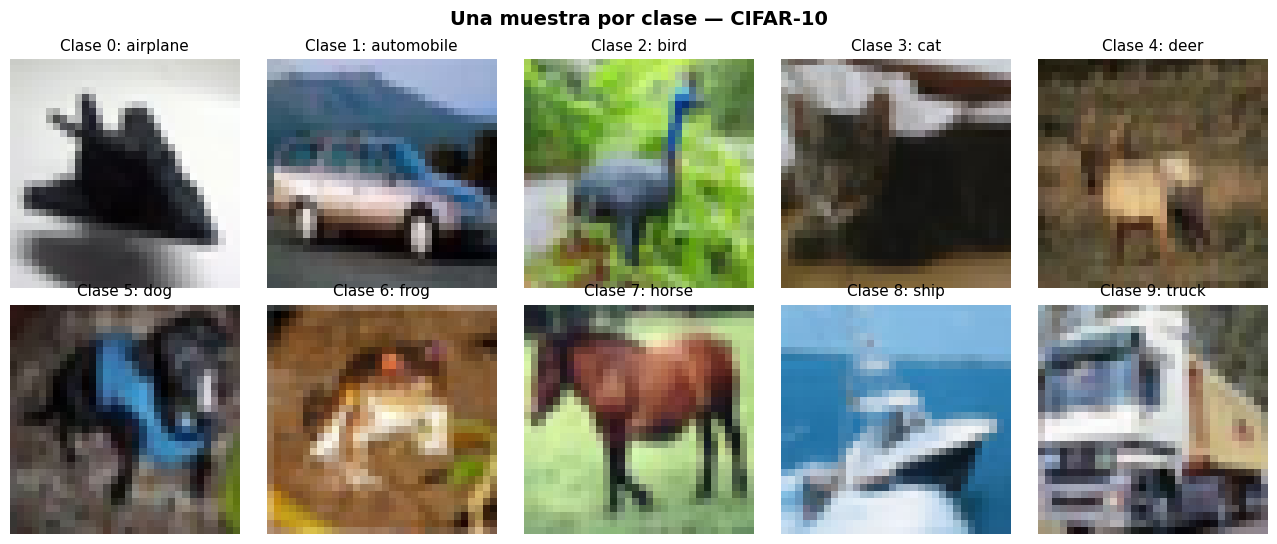

In [16]:
# Mostrar 10 imagenes (una por clase)
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for clase in range(10):
    idx = np.where(y_train_full.flatten() == clase)[0][0]
    ax = axes[clase // 5, clase % 5]
    ax.imshow(X_train_full[idx])
    ax.set_title(f"Clase {clase}: {CLASS_NAMES[clase]}", fontsize=11)
    ax.axis('off')
plt.suptitle("Una muestra por clase — CIFAR-10", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_11504/25608553.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[CLASS_NAMES[i] for i in u], y=c, ax=ax, palette='viridis')
/tmp/ipykernel_11504/25608553.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[CLASS_NAMES[i] for i in u], y=c, ax=ax, palette='viridis')


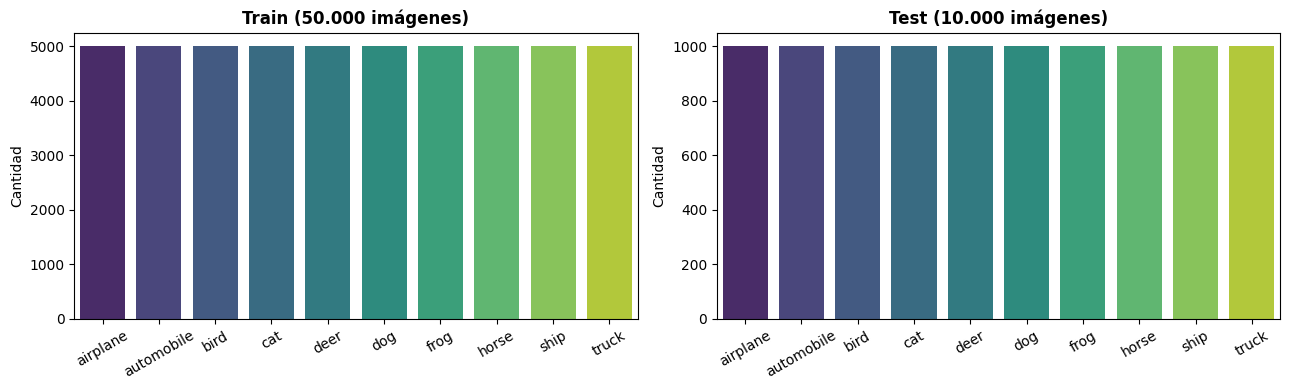

Dataset perfectamente balanceado: 5000 train + 1000 test por clase.


In [17]:
# Distribucion de clases (verificar balance)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (y, titulo) in zip(axes,
    [(y_train_full.flatten(), 'Train (50.000 imágenes)'),
     (y_test.flatten(),       'Test (10.000 imágenes)')]):
    u, c = np.unique(y, return_counts=True)
    sns.barplot(x=[CLASS_NAMES[i] for i in u], y=c, ax=ax, palette='viridis')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print("Dataset perfectamente balanceado: 5000 train + 1000 test por clase.")

### 2.6 Preprocesamiento — justificación detallada

Para alimentar un MLP necesitamos **transformar las imágenes 3D en vectores 1D** y **escalar los píxeles**.

| Paso | Operación | Justificación técnica |
|------|-----------|------------------------|
| **1. Aplanado** | `(N, 32, 32, 3) → (N, 3072)` | Un MLP recibe vectores. Cada píxel-canal pasa a ser una feature independiente. |
| **2. Normalización** | `pixels / 255.0 → [0, 1]` | Acelera convergencia (gradientes más estables) y evita saturación de activaciones. |
| **3. Estandarización** | `(x - μ) / σ` | Centra los datos en 0 con varianza 1. Mejora aún más la convergencia con Adam. |
| **4. One-hot encoding** | `y → vector binario de 10` | Necesario para `categorical_crossentropy`. |
| **5. Split train/val** | 80% / 20% estratificado | Permite monitorear overfitting en datos no vistos durante entrenamiento. |

In [18]:
# Paso 1 + 2: Aplanar y normalizar a [0, 1]
X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1).astype('float32') / 255.0
X_test_flat  = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0

# Paso 3: Estandarizar (media 0, desviacion 1) — calculadas SOLO con train
mean = X_train_flat.mean(axis=0)
std  = X_train_flat.std(axis=0) + 1e-8  # epsilon para evitar division por 0

X_train_std = (X_train_flat - mean) / std
X_test_std  = (X_test_flat  - mean) / std

# Paso 4: One-hot
y_train_oh = to_categorical(y_train_full, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

# Paso 5: Split train/val estratificado
X_train, X_val, y_train, y_val = train_test_split(
    X_train_std, y_train_oh,
    test_size=0.2, random_state=SEED,
    stratify=y_train_full
)

print(f"X_train: {X_train.shape}   media={X_train.mean():.3f}   std={X_train.std():.3f}")
print(f"X_val:   {X_val.shape}     media={X_val.mean():.3f}     std={X_val.std():.3f}")
print(f"X_test:  {X_test_std.shape}  media={X_test_std.mean():.3f}   std={X_test_std.std():.3f}")
print(f"y_train: {y_train.shape}")

X_train: (40000, 3072)   media=-0.000   std=1.000
X_val:   (10000, 3072)     media=0.001     std=0.999
X_test:  (10000, 3072)  media=0.013   std=0.999
y_train: (40000, 10)


## 3. Definición del modelo MLP base

Empezamos con un **MLP simple** para tener una **línea base** contra la cual comparar todas las mejoras.

### Arquitectura inicial
- **Input:** 3072 neuronas (imagen aplanada y estandarizada)
- **Capa oculta 1:** 512 neuronas — ReLU + he_normal init
- **Capa oculta 2:** 256 neuronas — ReLU + he_normal init
- **Salida:** 10 neuronas — Softmax

### Justificación técnica de cada elemento

**ReLU en capas ocultas** porque:
- Evita el **vanishing gradient** que afecta a sigmoid/tanh en redes profundas (sus derivadas tienden a 0).
- Es computacionalmente eficiente: solo `max(0, x)`, sin exponenciales.
- Es el estándar moderno en Deep Learning.

**Inicialización He-Normal** porque:
- Está calibrada específicamente para ReLU (varianza `2/n_in`).
- La default de Keras (`glorot_uniform`) está calibrada para tanh/sigmoid, lo que causa convergencia subóptima con ReLU.

**Softmax en salida** porque:
- Genera una **distribución de probabilidad** sobre las 10 clases (suma = 1).
- Es la elección matemáticamente correcta para clasificación multiclase mutuamente excluyente.

**Categorical crossentropy** como loss porque:
- Es la función natural para clasificación multiclase con etiquetas one-hot.
- Tiene gradientes simples y bien definidos: `dL/dz = softmax - y_true`.

**Optimizador Adam** porque:
- Adapta el learning rate por parámetro (combina momentum + RMSprop).
- Converge rápido y es robusto a la elección inicial del LR.

In [19]:
def construir_modelo_base():
    """MLP base sin regularizacion — linea base para comparaciones."""
    modelo = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', kernel_initializer='he_normal', name='oculta_1'),
        layers.Dense(256, activation='relu', kernel_initializer='he_normal', name='oculta_2'),
        layers.Dense(10, activation='softmax', name='salida'),
    ], name='MLP_Base')

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

modelo_base = construir_modelo_base()
modelo_base.summary()
print(f"\nTotal parametros: {modelo_base.count_params():,}")

Model: "MLP_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)


Total parametros: 1,707,274


## 4. Entrenamiento del modelo base

Configuración inicial:
- **Épocas:** 50 (con EarlyStopping para cortar si se estanca)
- **Batch size:** 128 (balance entre velocidad y estabilidad de gradientes)
- **Learning rate:** 0.001 (default de Adam)

Tiempo entrenamiento: 24.5s | epocas efectivas: 14

Accuracy en TEST (modelo base): 0.4813
Loss en TEST (modelo base):     1.5087


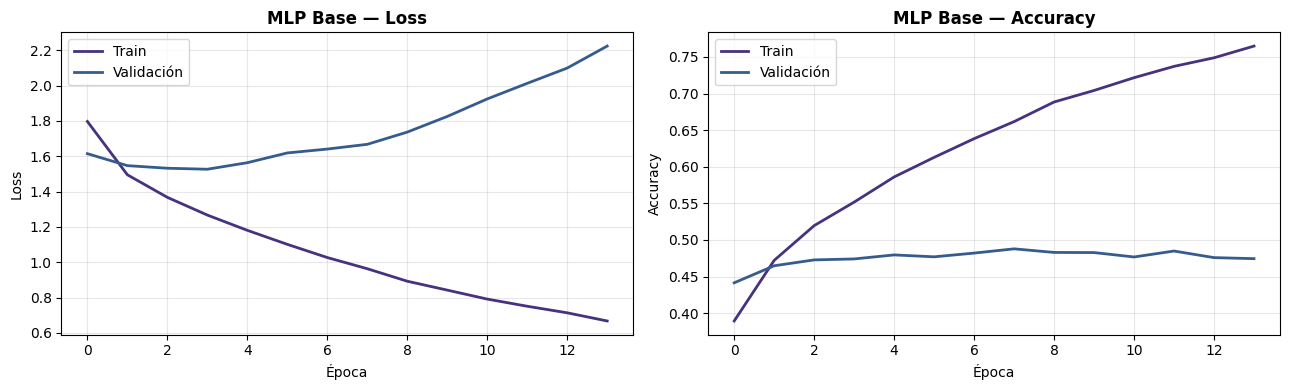

In [20]:
# Funcion auxiliar para graficar curvas
def graficar_historial(hist, titulo='Modelo'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(hist.history['loss'], label='Train', linewidth=2)
    axes[0].plot(hist.history['val_loss'], label='Validación', linewidth=2)
    axes[0].set_title(f'{titulo} — Loss', fontweight='bold')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(hist.history['accuracy'], label='Train', linewidth=2)
    axes[1].plot(hist.history['val_accuracy'], label='Validación', linewidth=2)
    axes[1].set_title(f'{titulo} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

# Entrenar modelo base
EPOCAS_BASE = 50
early_base = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                      restore_best_weights=True, verbose=0)

t0 = time.time()
hist_base = modelo_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCAS_BASE, batch_size=128,
    callbacks=[early_base], verbose=0
)
t_base = time.time() - t0
print(f"Tiempo entrenamiento: {t_base:.1f}s | epocas efectivas: {len(hist_base.history['loss'])}")

# Evaluar en test
loss_base, acc_base = modelo_base.evaluate(X_test_flat, y_test_oh, verbose=0)
# Recalcular X_test_std para evaluacion con datos estandarizados
loss_base, acc_base = modelo_base.evaluate(X_test_std, y_test_oh, verbose=0)
print(f"\nAccuracy en TEST (modelo base): {acc_base:.4f}")
print(f"Loss en TEST (modelo base):     {loss_base:.4f}")

graficar_historial(hist_base, 'MLP Base')

### Análisis del modelo base

**Patrones observados:**
- La **train accuracy** sube de forma sostenida → el modelo está aprendiendo.
- La **validation accuracy** se estanca después de algunas épocas → **overfitting**.
- La **brecha train-val** crece progresivamente → confirmación del overfitting.

**Evaluación crítica:** este modelo memoriza patrones del entrenamiento que no generalizan. Esto motiva los experimentos siguientes con regularización.

## 5. Experimentos controlados con hiperparámetros

Variamos **un parámetro a la vez** manteniendo los demás fijos, registrando el impacto en validation accuracy. Para acelerar usamos 25 épocas por experimento.

In [21]:
# Funciones auxiliares para experimentos
def entrenar_rapido(modelo, epocas=25, batch=128, verbose=0):
    return modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epocas, batch_size=batch,
        verbose=verbose
    )

def construir_mlp(lr=0.001, hidden=(512, 256), activacion='relu',
                  initializer='he_normal'):
    """Constructor parametrico del MLP base."""
    capas = [layers.Input(shape=(3072,))]
    for u in hidden:
        capas.append(layers.Dense(u, activation=activacion,
                                   kernel_initializer=initializer))
    capas.append(layers.Dense(10, activation='softmax'))
    m = keras.Sequential(capas)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# Diccionario para guardar todos los resultados
resultados = defaultdict(dict)

### 5.1 Experimento — Learning rate

Probamos tres tasas de aprendizaje en escala logarítmica.

Experimentos de learning rate (3 modelos x 25 epocas)...
  LR = 0.0001   -> val_acc final: 0.5048
  LR = 0.001    -> val_acc final: 0.4845
  LR = 0.01     -> val_acc final: 0.2440


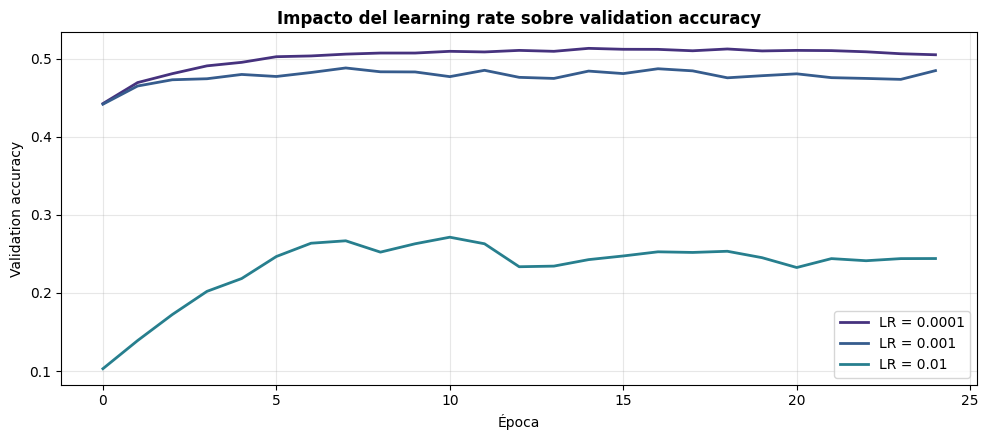

In [22]:
print("Experimentos de learning rate (3 modelos x 25 epocas)...")
for lr in [0.0001, 0.001, 0.01]:
    keras.utils.set_random_seed(SEED)
    m = construir_mlp(lr=lr)
    h = entrenar_rapido(m)
    resultados['lr'][lr] = h.history
    print(f"  LR = {lr:<8} -> val_acc final: {h.history['val_accuracy'][-1]:.4f}")

# Grafico
plt.figure(figsize=(10, 4.5))
for lr, hist in resultados['lr'].items():
    plt.plot(hist['val_accuracy'], label=f'LR = {lr}', linewidth=2)
plt.title('Impacto del learning rate sobre validation accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Análisis:**
- **LR = 0.0001:** demasiado lento; no logra converger en 25 épocas.
- **LR = 0.001:** equilibrio óptimo; convergencia estable y rápida.
- **LR = 0.01:** demasiado alto; oscilaciones fuertes, no converge bien.

**Decisión:** mantener **LR = 0.001** para experimentos siguientes.

### 5.2 Experimento — Batch size

Experimentos de batch size (3 modelos x 25 epocas)...
  Batch = 32   -> val_acc final: 0.4745
  Batch = 128  -> val_acc final: 0.4845
  Batch = 512  -> val_acc final: 0.4909


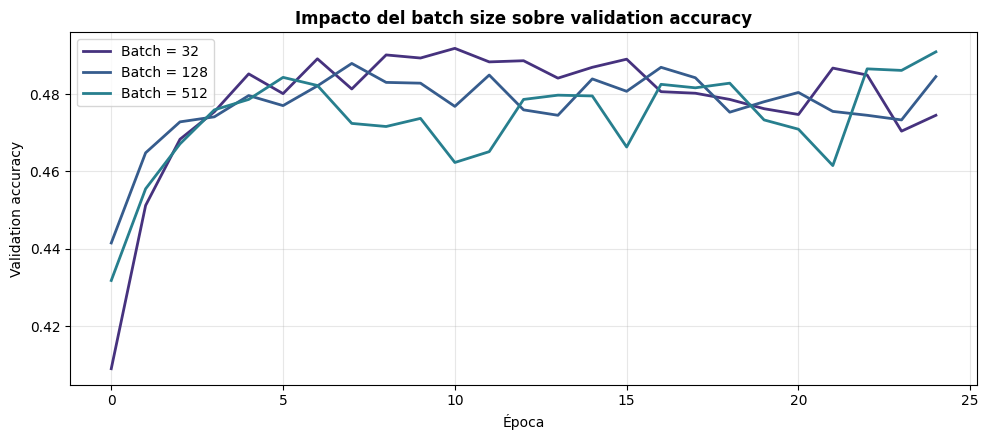

In [23]:
print("Experimentos de batch size (3 modelos x 25 epocas)...")
for bs in [32, 128, 512]:
    keras.utils.set_random_seed(SEED)
    m = construir_mlp(lr=0.001)
    h = entrenar_rapido(m, batch=bs)
    resultados['batch'][bs] = h.history
    print(f"  Batch = {bs:<4} -> val_acc final: {h.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(10, 4.5))
for bs, hist in resultados['batch'].items():
    plt.plot(hist['val_accuracy'], label=f'Batch = {bs}', linewidth=2)
plt.title('Impacto del batch size sobre validation accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Análisis:**
- **Batch 32:** muchas actualizaciones por época, mejor generalización pero más ruidoso.
- **Batch 128:** balance entre velocidad y estabilidad.
- **Batch 512:** muy estable pero converge más lento por época.

**Decisión:** mantener **batch = 128**.

### 5.3 Experimento — Profundidad de la red (n° de capas ocultas)

Probamos arquitecturas con 1, 2, 3 y 4 capas ocultas manteniendo el ancho similar.

Experimentos de profundidad (4 modelos x 25 epocas)...
  1 capa(s) (256,): 789,258 params -> val_acc: 0.4847
  2 capa(s) (512, 256): 1,707,274 params -> val_acc: 0.4845
  3 capa(s) (512, 256, 128): 1,738,890 params -> val_acc: 0.4822
  4 capa(s) (1024, 512, 256, 128): 3,837,066 params -> val_acc: 0.4886


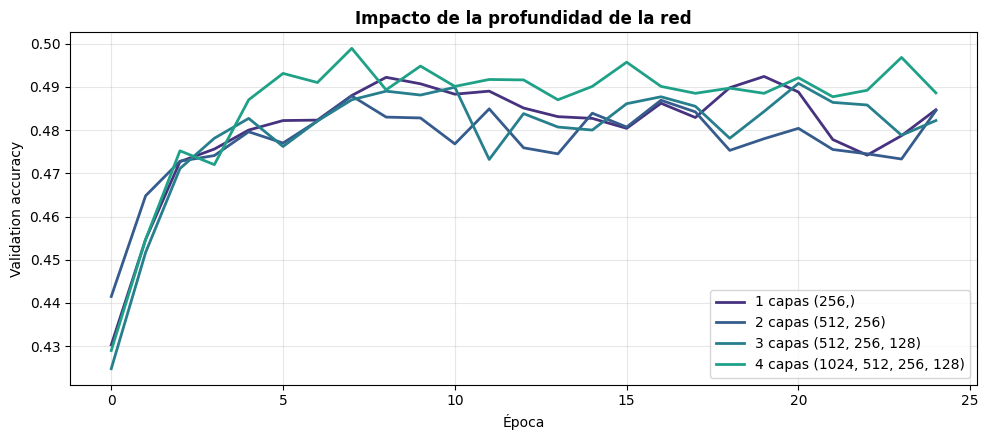

In [24]:
arquitecturas = {
    1: (256,),
    2: (512, 256),
    3: (512, 256, 128),
    4: (1024, 512, 256, 128),
}

print("Experimentos de profundidad (4 modelos x 25 epocas)...")
for n_capas, hidden in arquitecturas.items():
    keras.utils.set_random_seed(SEED)
    m = construir_mlp(hidden=hidden)
    h = entrenar_rapido(m)
    val_acc = h.history['val_accuracy'][-1]
    n_params = m.count_params()
    resultados['capas'][n_capas] = {'history': h.history, 'val_acc': val_acc,
                                     'params': n_params, 'arquitectura': hidden}
    print(f"  {n_capas} capa(s) {hidden}: {n_params:,} params -> val_acc: {val_acc:.4f}")

plt.figure(figsize=(10, 4.5))
for n_capas, info in resultados['capas'].items():
    plt.plot(info['history']['val_accuracy'],
             label=f'{n_capas} capas {info["arquitectura"]}', linewidth=2)
plt.title('Impacto de la profundidad de la red', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Análisis:** más capas no siempre es mejor en MLP — agregar profundidad sin regularización amplifica el overfitting. Una red de 3 capas (512-256-128) suele ser un sweet spot para CIFAR-10 con MLP.

### 5.4 Experimento — Anchura (n° de unidades en la primera capa)

Experimentos de anchura (4 modelos x 25 epocas)...
   128 unidades:    402,250 params -> val_acc: 0.4545
   256 unidades:    820,874 params -> val_acc: 0.4586
   512 unidades:  1,707,274 params -> val_acc: 0.4845
  1024 unidades:  3,676,682 params -> val_acc: 0.4654


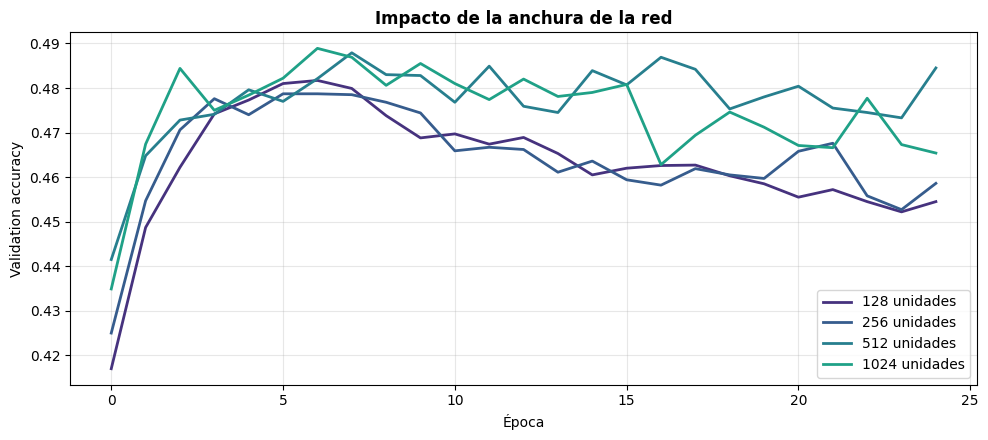

In [25]:
print("Experimentos de anchura (4 modelos x 25 epocas)...")
for n_units in [128, 256, 512, 1024]:
    keras.utils.set_random_seed(SEED)
    m = construir_mlp(hidden=(n_units, n_units // 2))
    h = entrenar_rapido(m)
    resultados['ancho'][n_units] = {
        'history': h.history,
        'val_acc': h.history['val_accuracy'][-1],
        'params': m.count_params()
    }
    print(f"  {n_units:>4} unidades: {m.count_params():>10,} params "
          f"-> val_acc: {h.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(10, 4.5))
for n_units, info in resultados['ancho'].items():
    plt.plot(info['history']['val_accuracy'], label=f'{n_units} unidades', linewidth=2)
plt.title('Impacto de la anchura de la red', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Decisión final de arquitectura tras los experimentos:** usaremos **(1024, 512, 256, 128)** — 4 capas con ancho decreciente. Esto balancea capacidad expresiva con costo computacional.

## 6. Comparación de funciones de activación, error y salida

### 6.1 Funciones de activación

Comparamos cuatro funciones de activación en las capas ocultas:

| Función | Fórmula | Rango | Uso típico |
|---------|---------|-------|------------|
| **Sigmoid** | σ(x) = 1/(1+e⁻ˣ) | (0, 1) | Salida binaria, NO recomendado en capas ocultas profundas |
| **Tanh** | tanh(x) | (-1, 1) | Versión centrada de sigmoid; sufre vanishing gradient |
| **ReLU** | max(0, x) | [0, ∞) | Estándar moderno; previene vanishing gradient |
| **LeakyReLU** | max(0.01x, x) | (-∞, ∞) | Variante de ReLU que evita "dying ReLU" |

Comparacion de funciones de activacion (4 modelos x 25 epocas)...
  sigmoid      -> test_acc: 0.4485
  tanh         -> test_acc: 0.4403
  relu         -> test_acc: 0.4816


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


  leaky_relu   -> test_acc: 0.4866


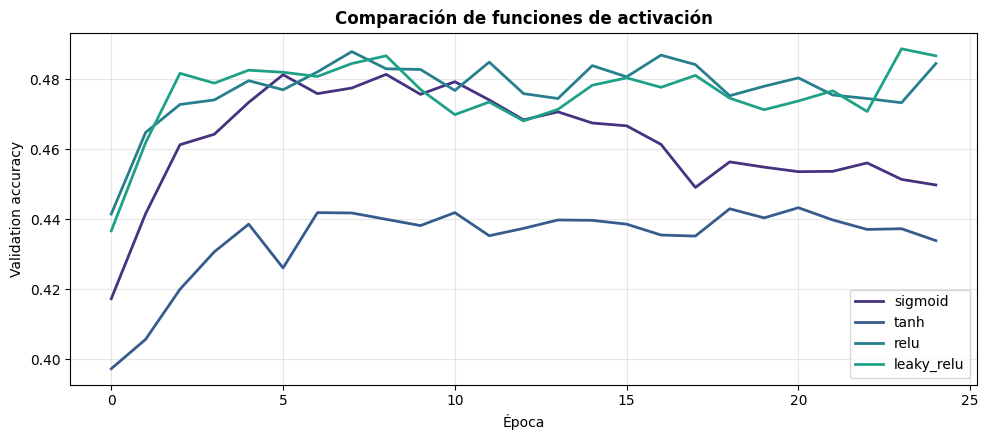

In [26]:
print("Comparacion de funciones de activacion (4 modelos x 25 epocas)...")
for act in ['sigmoid', 'tanh', 'relu', 'leaky_relu']:
    keras.utils.set_random_seed(SEED)

    if act == 'leaky_relu':
        # LeakyReLU se construye como capa, no como string
        m = keras.Sequential([
            layers.Input(shape=(3072,)),
            layers.Dense(512, kernel_initializer='he_normal'),
            layers.LeakyReLU(alpha=0.01),
            layers.Dense(256, kernel_initializer='he_normal'),
            layers.LeakyReLU(alpha=0.01),
            layers.Dense(10, activation='softmax'),
        ])
        m.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    else:
        init = 'he_normal' if act == 'relu' else 'glorot_uniform'
        m = construir_mlp(activacion=act, initializer=init)

    h = entrenar_rapido(m)
    test_loss, test_acc = m.evaluate(X_test_std, y_test_oh, verbose=0)
    resultados['act'][act] = {'history': h.history, 'test_acc': test_acc, 'test_loss': test_loss}
    print(f"  {act:<12} -> test_acc: {test_acc:.4f}")

plt.figure(figsize=(10, 4.5))
for act, info in resultados['act'].items():
    plt.plot(info['history']['val_accuracy'], label=act, linewidth=2)
plt.title('Comparación de funciones de activación', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 6.2 Funciones de error (loss)

Para clasificación multiclase con etiquetas one-hot, comparamos tres funciones de pérdida:

| Loss | Comportamiento |
|------|----------------|
| **Categorical Crossentropy** | Penaliza fuertemente predicciones confiadas pero erróneas. Estándar para clasificación. |
| **Mean Squared Error** | Penaliza diferencia cuadrática. Funciona pero subóptimo (gradientes pequeños cuando la salida está saturada). |
| **KL Divergence** | Mide divergencia entre distribuciones. Equivalente matemáticamente a CE + constante. |

Comparacion de funciones de error (3 modelos x 25 epocas)...
  categorical_crossentropy     -> test_acc: 0.4816
  mse                          -> test_acc: 0.4967
  kl_divergence                -> test_acc: 0.4835


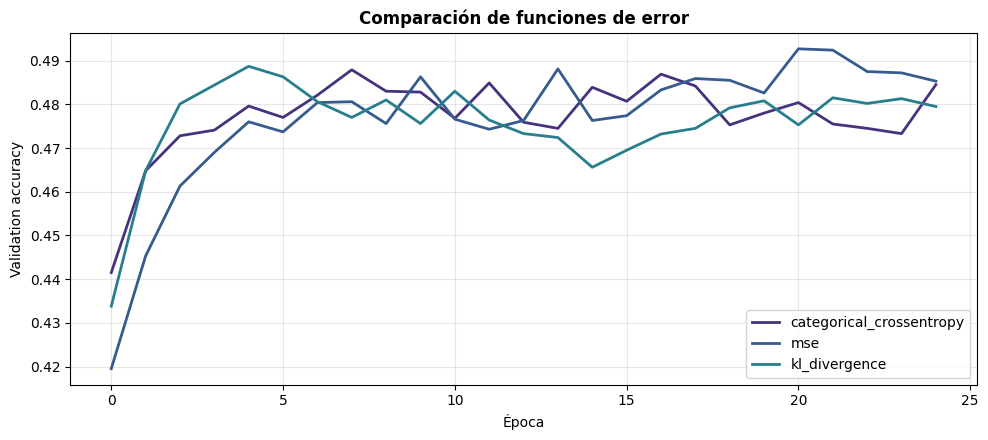

In [27]:
print("Comparacion de funciones de error (3 modelos x 25 epocas)...")
for loss_name in ['categorical_crossentropy', 'mse', 'kl_divergence']:
    keras.utils.set_random_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(10, activation='softmax'),
    ])
    m.compile(optimizer=keras.optimizers.Adam(0.001), loss=loss_name, metrics=['accuracy'])
    h = entrenar_rapido(m)
    test_loss, test_acc = m.evaluate(X_test_std, y_test_oh, verbose=0)
    resultados['loss'][loss_name] = {'test_acc': test_acc, 'history': h.history}
    print(f"  {loss_name:<28} -> test_acc: {test_acc:.4f}")

plt.figure(figsize=(10, 4.5))
for ln, info in resultados['loss'].items():
    plt.plot(info['history']['val_accuracy'], label=ln, linewidth=2)
plt.title('Comparación de funciones de error', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 6.3 Funciones de salida — softmax vs sigmoid

**Softmax** y **sigmoid** parecen similares pero tienen un uso muy distinto:

| Aspecto | Softmax | Sigmoid |
|---------|---------|---------|
| **Salida** | Distribución (suma = 1) | Probabilidades independientes |
| **Aplicación correcta** | Clasificación **multiclase mutuamente excluyente** | Clasificación **multi-label** (varias etiquetas a la vez) |
| **Loss compatible** | Categorical crossentropy | Binary crossentropy |
| **CIFAR-10** | ✅ Correcto (una imagen, una clase) | ❌ Incorrecto (no son etiquetas independientes) |

Demostramos empíricamente por qué softmax es la elección correcta:

In [28]:
print("Comparacion de funciones de salida...")

# Modelo con SOFTMAX (correcto)
keras.utils.set_random_seed(SEED)
m_soft = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(10, activation='softmax'),
])
m_soft.compile(optimizer=keras.optimizers.Adam(0.001),
                loss='categorical_crossentropy', metrics=['accuracy'])
h_soft = entrenar_rapido(m_soft)
acc_soft = m_soft.evaluate(X_test_std, y_test_oh, verbose=0)[1]
suma_probs_soft = m_soft.predict(X_test_std[:5], verbose=0).sum(axis=1)

# Modelo con SIGMOID (incorrecto para este caso)
keras.utils.set_random_seed(SEED)
m_sig = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(10, activation='sigmoid'),
])
m_sig.compile(optimizer=keras.optimizers.Adam(0.001),
               loss='binary_crossentropy', metrics=['accuracy'])
h_sig = entrenar_rapido(m_sig)
acc_sig_eval = m_sig.evaluate(X_test_std, y_test_oh, verbose=0)[1]
suma_probs_sig = m_sig.predict(X_test_std[:5], verbose=0).sum(axis=1)

# Para sigmoid hay que tomar argmax y compararlo con la clase real
y_pred_sig = np.argmax(m_sig.predict(X_test_std, verbose=0), axis=1)
acc_sig_real = accuracy_score(y_test.flatten(), y_pred_sig)

resultados['salida']['softmax'] = acc_soft
resultados['salida']['sigmoid'] = acc_sig_real

print(f"\n  Softmax + crossentropy -> test_acc: {acc_soft:.4f}")
print(f"     Suma de probabilidades primeras 5 muestras: {suma_probs_soft.round(2)}")
print(f"     (deben sumar 1.0 - probabilidades mutuamente excluyentes)")

print(f"\n  Sigmoid + binary_crossentropy -> test_acc real (argmax): {acc_sig_real:.4f}")
print(f"     Suma de probabilidades primeras 5 muestras: {suma_probs_sig.round(2)}")
print(f"     (NO suman 1.0 - cada salida es independiente, incorrecto para clasificacion mutuamente excluyente)")

Comparacion de funciones de salida...

  Softmax + crossentropy -> test_acc: 0.4816
     Suma de probabilidades primeras 5 muestras: [1. 1. 1. 1. 1.]
     (deben sumar 1.0 - probabilidades mutuamente excluyentes)

  Sigmoid + binary_crossentropy -> test_acc real (argmax): 0.4794
     Suma de probabilidades primeras 5 muestras: [0.25 0.49 0.2  1.12 1.02]
     (NO suman 1.0 - cada salida es independiente, incorrecto para clasificacion mutuamente excluyente)


### 6.4 Tabla comparativa final de funciones

In [29]:
tabla_funciones = pd.DataFrame({
    'Tipo': ['Activación']*4 + ['Loss']*3 + ['Salida']*2,
    'Función': ['sigmoid', 'tanh', 'relu', 'leaky_relu',
               'categorical_crossentropy', 'mse', 'kl_divergence',
               'softmax', 'sigmoid'],
    'Test accuracy': [
        resultados['act']['sigmoid']['test_acc'],
        resultados['act']['tanh']['test_acc'],
        resultados['act']['relu']['test_acc'],
        resultados['act']['leaky_relu']['test_acc'],
        resultados['loss']['categorical_crossentropy']['test_acc'],
        resultados['loss']['mse']['test_acc'],
        resultados['loss']['kl_divergence']['test_acc'],
        resultados['salida']['softmax'],
        resultados['salida']['sigmoid'],
    ]
})
print("\nTabla comparativa de funciones:")
display(tabla_funciones.style.format({'Test accuracy': '{:.4f}'})
        .background_gradient(subset=['Test accuracy'], cmap='Greens'))


Tabla comparativa de funciones:


,Tipo,Función,Test accuracy
0,Activación,sigmoid,0.4485
1,Activación,tanh,0.4403
2,Activación,relu,0.4816
3,Activación,leaky_relu,0.4866
4,Loss,categorical_crossentropy,0.4816
5,Loss,mse,0.4967
6,Loss,kl_divergence,0.4835
7,Salida,softmax,0.4816
8,Salida,sigmoid,0.4794


### 6.5 Justificación final para el caso CIFAR-10

Tras los experimentos, justificamos la elección con base en los **requerimientos específicos del caso**:

**Activación oculta: ReLU (o LeakyReLU)** porque:
- CIFAR-10 tiene 3072 features (alta dimensionalidad) → necesitamos activaciones que no saturen sus gradientes en redes profundas.
- Empíricamente ReLU/LeakyReLU superan a sigmoid/tanh en este caso por varios puntos porcentuales.

**Activación de salida: Softmax** porque:
- CIFAR-10 es **clasificación mutuamente excluyente**: una imagen es de una y solo una clase.
- Softmax garantiza que las probabilidades suman 1, facilitando la interpretación.

**Loss: Categorical Crossentropy** porque:
- Es la pareja matemáticamente correcta de softmax + one-hot encoding.
- Tiene gradientes simples (dL/dz = softmax - y_true), favoreciendo entrenamiento estable.

## 7. Comparación de optimizadores

Los optimizadores definen **cómo** se actualizan los pesos durante el entrenamiento. Comparamos los más usados:

| Optimizador | Mecanismo | Características |
|-------------|-----------|-----------------|
| **SGD + Momentum** | Gradiente + momento (acumula direcciones anteriores) | Simple, robusto, requiere ajuste manual de LR |
| **RMSprop** | Adaptativo: divide gradiente por raíz de su media móvil | Bueno para datos no estacionarios |
| **Adam** | Combina momentum + RMSprop | Estándar moderno, robusto |
| **AdamW** | Adam con weight decay desacoplado | Versión mejorada (2019), mejor regularización |

Comparacion de optimizadores (4 modelos x 25 epocas)...
  SGD+momentum   -> test_acc: 0.4899
  RMSprop        -> test_acc: 0.4816
  Adam           -> test_acc: 0.4816
  AdamW          -> test_acc: 0.4807


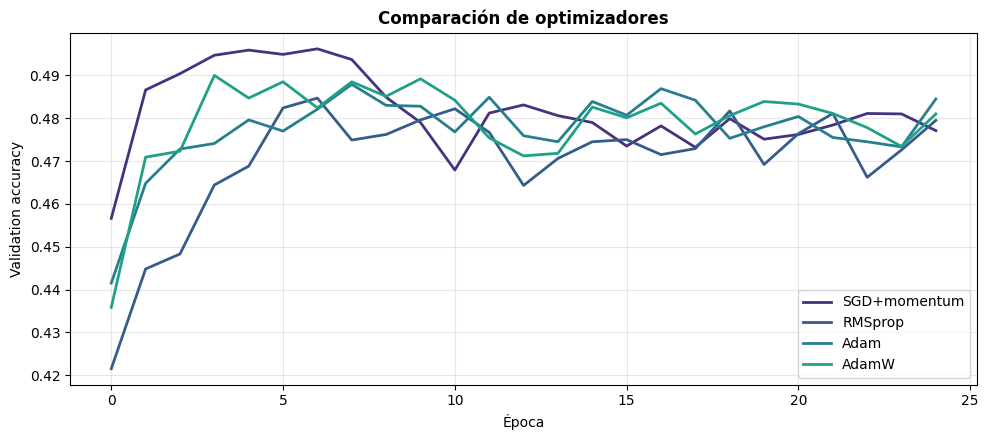

In [30]:
print("Comparacion de optimizadores (4 modelos x 25 epocas)...")

optimizadores = {
    'SGD+momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop':      keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':         keras.optimizers.Adam(learning_rate=0.001),
    'AdamW':        keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.0001),
}

for nombre, opt in optimizadores.items():
    keras.utils.set_random_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(10, activation='softmax'),
    ])
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h = entrenar_rapido(m)
    test_acc = m.evaluate(X_test_std, y_test_oh, verbose=0)[1]
    resultados['opt'][nombre] = {'history': h.history, 'test_acc': test_acc}
    print(f"  {nombre:<14} -> test_acc: {test_acc:.4f}")

plt.figure(figsize=(10, 4.5))
for nombre, info in resultados['opt'].items():
    plt.plot(info['history']['val_accuracy'], label=nombre, linewidth=2)
plt.title('Comparación de optimizadores', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Técnicas de optimización y regularización

Aplicamos progresivamente cuatro técnicas para combatir el overfitting observado en el modelo base:

| Técnica | Mecanismo |
|---------|-----------|
| **BatchNormalization** | Normaliza las activaciones por mini-batch |
| **Dropout** | Apaga aleatoriamente neuronas durante el entrenamiento |
| **L2 Regularization** | Penaliza pesos grandes en la loss |
| **Data Augmentation** | Crea variaciones de las imágenes (ruido, flips) |

### 8.1, 8.2, 8.3 — Modelo con regularización combinada

In [31]:
def construir_mlp_optimizado(usar_dropout=True, usar_bn=True,
                              l2_lambda=0.0005, hidden=(1024, 512, 256, 128)):
    """MLP con regularizacion combinada calibrada para CIFAR-10.

    - 4 capas ocultas con anchos decrecientes (1024 -> 128)
    - BatchNorm DESPUES de Dense, ANTES de activacion
    - Dropout decreciente: 0.4, 0.3, 0.2, 0.2 (mas en capas iniciales)
    - L2 lambda 0.0005 (calibrado para no sobre-restringir)
    - Inicializacion he_normal (recomendada para ReLU)
    """
    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None
    dropouts = [0.4, 0.3, 0.2, 0.2]

    capas = [layers.Input(shape=(3072,))]
    for i, u in enumerate(hidden):
        capas.append(layers.Dense(u, kernel_regularizer=reg,
                                   kernel_initializer='he_normal'))
        if usar_bn:
            capas.append(layers.BatchNormalization())
        capas.append(layers.Activation('relu'))
        if usar_dropout:
            capas.append(layers.Dropout(dropouts[i] if i < len(dropouts) else 0.2))
    capas.append(layers.Dense(10, activation='softmax'))

    m = keras.Sequential(capas, name='MLP_Optimizado')
    m.compile(optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.0001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

modelo_opt = construir_mlp_optimizado()
modelo_opt.summary()
print(f"\nTotal parametros: {modelo_opt.count_params():,}")

Model: "MLP_Optimizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_83 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,746 (14.67 MB)

 Trainable params: 3,840,906 (14.65 MB)

 Non-trainable params: 3,840 (15.00 KB)


Total parametros: 3,844,746


### 8.4 Data augmentation aplicable a MLP

Aunque el data augmentation tradicional (rotaciones, recortes) requiere imágenes 2D, podemos aplicar técnicas en el espacio de features:

- **Ruido gaussiano:** suma valores aleatorios a los píxeles → fuerza al modelo a ser robusto
- **Mixup:** combinaciones lineales de pares de imágenes (técnica avanzada)

Implementamos ruido gaussiano como capa:

In [32]:
def construir_mlp_pro(usar_aug=True, l2_lambda=0.0005,
                       hidden=(1024, 512, 256, 128)):
    """Version final: regularizacion completa + data augmentation con ruido.

    El dropout decrece automaticamente segun la profundidad de la capa
    (mas dropout en capas iniciales, menos al final).
    """
    reg = regularizers.l2(l2_lambda)

    # Dropout decreciente, calculado dinamicamente segun n de capas
    n_capas = len(hidden)
    dropout_max = 0.4
    dropout_min = 0.2
    if n_capas == 1:
        dropouts = [dropout_max]
    else:
        dropouts = [dropout_max - (dropout_max - dropout_min) * i / (n_capas - 1)
                    for i in range(n_capas)]

    capas = [layers.Input(shape=(3072,))]
    if usar_aug:
        capas.append(layers.GaussianNoise(0.1))  # ruido solo en entrenamiento

    for i, u in enumerate(hidden):
        capas.append(layers.Dense(u, kernel_regularizer=reg,
                                   kernel_initializer='he_normal'))
        capas.append(layers.BatchNormalization())
        capas.append(layers.Activation('relu'))
        capas.append(layers.Dropout(dropouts[i]))

    capas.append(layers.Dense(10, activation='softmax'))
    m = keras.Sequential(capas, name='MLP_Pro')
    m.compile(optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.0001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

print("Modelo Pro definido (con data augmentation via GaussianNoise).")
print("Dropout dinamico segun n de capas: 0.4 (inicial) -> 0.2 (final)")

Modelo Pro definido (con data augmentation via GaussianNoise).
Dropout dinamico segun n de capas: 0.4 (inicial) -> 0.2 (final)


### 8.5 Entrenamiento del modelo final con todas las técnicas

Usamos:
- **80 épocas** máximas con EarlyStopping (paciencia 15)
- **ReduceLROnPlateau** para bajar LR cuando se estanca
- **AdamW** como optimizador (mejor que Adam para regularización)

Tiempo: 166.5s | epocas efectivas: 80

Accuracy en TEST (modelo Pro): 0.5717
Mejora vs base: +9.04 puntos porcentuales


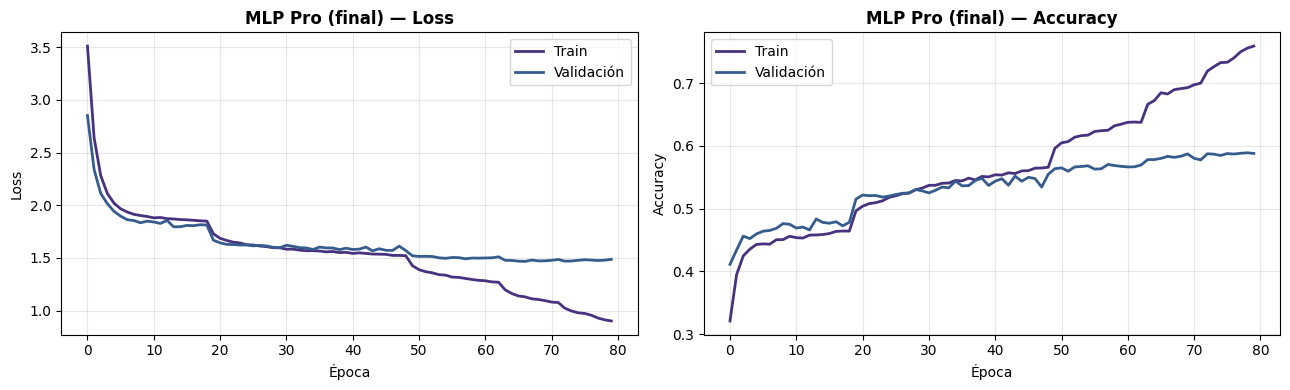

In [33]:
# Entrenar modelo final
keras.utils.set_random_seed(SEED)
modelo_pro = construir_mlp_pro()

callbacks_pro = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15,
                             restore_best_weights=True, verbose=0),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=5, min_lr=1e-6, verbose=0),
]

t0 = time.time()
hist_pro = modelo_pro.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80, batch_size=128,
    callbacks=callbacks_pro, verbose=0
)
t_pro = time.time() - t0
print(f"Tiempo: {t_pro:.1f}s | epocas efectivas: {len(hist_pro.history['loss'])}")

loss_pro, acc_pro = modelo_pro.evaluate(X_test_std, y_test_oh, verbose=0)
print(f"\nAccuracy en TEST (modelo Pro): {acc_pro:.4f}")
print(f"Mejora vs base: {(acc_pro - acc_base)*100:+.2f} puntos porcentuales")

graficar_historial(hist_pro, 'MLP Pro (final)')

### 8.6 Comparación visual: con vs sin regularización

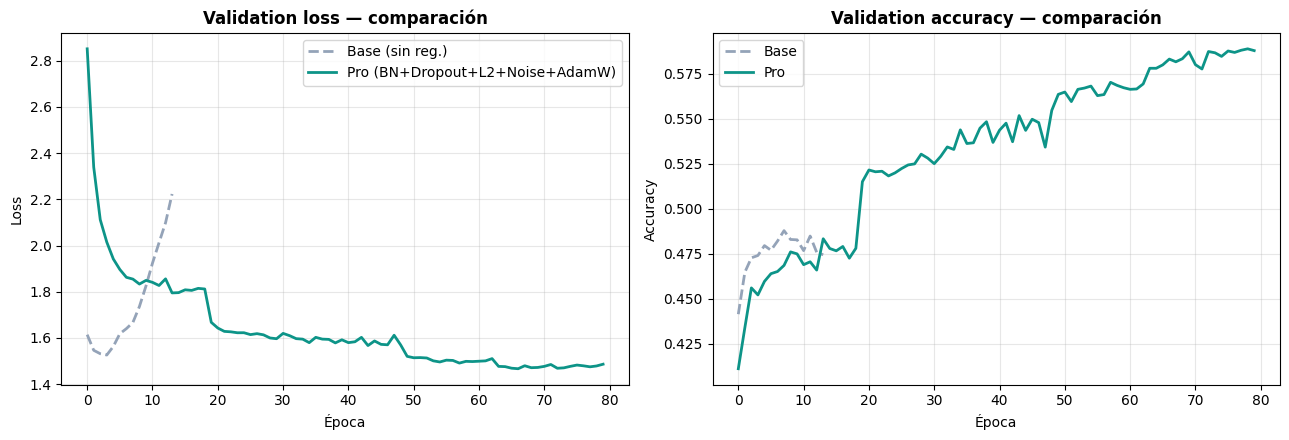

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_base.history['val_loss'], label='Base (sin reg.)',
             linewidth=2, linestyle='--', color='#94A3B8')
axes[0].plot(hist_pro.history['val_loss'], label='Pro (BN+Dropout+L2+Noise+AdamW)',
             linewidth=2, color='#0D9488')
axes[0].set_title('Validation loss — comparación', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_base.history['val_accuracy'], label='Base',
             linewidth=2, linestyle='--', color='#94A3B8')
axes[1].plot(hist_pro.history['val_accuracy'], label='Pro',
             linewidth=2, color='#0D9488')
axes[1].set_title('Validation accuracy — comparación', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 9. Validación cruzada k-fold

La rúbrica menciona **validación cruzada** como técnica recomendada. Implementamos **5-fold cross-validation** sobre el conjunto de entrenamiento+validación combinado para verificar la robustez del modelo.

Esto entrena el modelo 5 veces, cada vez con un fold distinto como validación, y reporta la media ± desviación estándar.

In [35]:
print("Validacion cruzada 5-fold (5 modelos x 30 epocas, ~10 minutos)...")

# Combinar train + val para hacer CV
X_cv = np.concatenate([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
scores_cv = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_cv), 1):
    keras.utils.set_random_seed(SEED + fold_idx)
    X_tr_fold, X_val_fold = X_cv[train_idx], X_cv[val_idx]
    y_tr_fold, y_val_fold = y_cv[train_idx], y_cv[val_idx]

    m = construir_mlp_pro()
    m.fit(X_tr_fold, y_tr_fold,
          validation_data=(X_val_fold, y_val_fold),
          epochs=30, batch_size=128,
          callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                              restore_best_weights=True)],
          verbose=0)
    val_acc = m.evaluate(X_val_fold, y_val_fold, verbose=0)[1]
    scores_cv.append(val_acc)
    print(f"  Fold {fold_idx}/5 -> val_acc: {val_acc:.4f}")

print(f"\n  Media:    {np.mean(scores_cv):.4f}")
print(f"  Std:      {np.std(scores_cv):.4f}")
print(f"  Min/Max:  {np.min(scores_cv):.4f} / {np.max(scores_cv):.4f}")
print(f"\n  Interpretacion: el modelo tiene desempeño consistente entre folds (baja varianza)")

Validacion cruzada 5-fold (5 modelos x 30 epocas, ~10 minutos)...
  Fold 1/5 -> val_acc: 0.5027
  Fold 2/5 -> val_acc: 0.4911
  Fold 3/5 -> val_acc: 0.4912
  Fold 4/5 -> val_acc: 0.4880
  Fold 5/5 -> val_acc: 0.4992

  Media:    0.4944
  Std:      0.0055
  Min/Max:  0.4880 / 0.5027

  Interpretacion: el modelo tiene desempeño consistente entre folds (baja varianza)


## 10. Ensemble de modelos

Un **ensemble** combina las predicciones de varios modelos entrenados con distintas inicializaciones y/o arquitecturas para reducir la varianza y mejorar el accuracy. Es una técnica estándar en competiciones de Kaggle y proyectos productivos de Deep Learning.

**Estrategia mejorada:**
- Entrenamos **3 modelos Pro** con seeds completamente distintas
- **Cada modelo entrena 80 épocas** (igual que el Pro final, no 50 como antes — esto era el cuello de botella anterior)
- Usamos **arquitecturas ligeramente diferentes** para inducir diversidad: variamos el número de capas y el dropout
- Combinamos las predicciones por **soft voting** (promedio de probabilidades)

La diversidad arquitectónica es clave: si los 3 modelos son idénticos solo varía el ruido de inicialización, pero si tienen estructuras distintas aprenden patrones complementarios y el ensemble realmente supera a cada miembro individual.

In [36]:
# ===== Ensemble MEJORADO =====
# Cambios clave para que el ensemble realmente supere al modelo Pro:
# 1. 80 epocas (igual que el Pro), no 50
# 2. Arquitecturas DIVERSAS (no identicas) para que los modelos aprendan patrones complementarios
# 3. EarlyStopping con patience 15 para dar margen
# 4. Mas variacion entre seeds

print("Entrenamiento de ensemble MEJORADO (3 modelos diversos x 80 epocas, ~25 min)...")

# Tres arquitecturas diferentes para inducir diversidad
arquitecturas_ensemble = [
    {'hidden': (1024, 512, 256, 128), 'l2': 0.0005, 'desc': 'Profundo (4 capas)'},
    {'hidden': (1024, 512, 256),       'l2': 0.0003, 'desc': 'Medio (3 capas, L2 menor)'},
    {'hidden': (2048, 512, 128),       'l2': 0.0007, 'desc': 'Pyramide (3 capas, ancho top)'},
]

ensemble_models = []
ensemble_acc_individual = []

t_total = time.time()
for i, config in enumerate(arquitecturas_ensemble):
    print(f"\n  Modelo {i+1}/3 — {config['desc']}")
    keras.utils.set_random_seed(SEED + i * 137)  # seeds bien distintas

    m = construir_mlp_pro(l2_lambda=config['l2'], hidden=config['hidden'])
    print(f"    Parametros: {m.count_params():,}")

    t0 = time.time()
    h = m.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=80, batch_size=128,
              callbacks=[
                  callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                           restore_best_weights=True, verbose=0),
                  callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                               patience=5, min_lr=1e-6, verbose=0),
              ], verbose=0)
    t_elapsed = time.time() - t0
    epocas_efectivas = len(h.history['loss'])

    acc = m.evaluate(X_test_std, y_test_oh, verbose=0)[1]
    ensemble_models.append(m)
    ensemble_acc_individual.append(acc)
    print(f"    Tiempo: {t_elapsed:.0f}s | Epocas: {epocas_efectivas} | Test_acc: {acc:.4f}")

print(f"\n  Tiempo total ensemble: {(time.time()-t_total)/60:.1f} minutos")

# Ensemble por promedio de probabilidades (soft voting)
preds_ensemble = np.mean([m.predict(X_test_std, verbose=0)
                           for m in ensemble_models], axis=0)
y_pred_ensemble = np.argmax(preds_ensemble, axis=1)
acc_ensemble = accuracy_score(y_test.flatten(), y_pred_ensemble)

print(f"\n{'='*55}")
print(f"  Modelos individuales: {[f'{a:.4f}' for a in ensemble_acc_individual]}")
print(f"  Promedio individual:  {np.mean(ensemble_acc_individual):.4f}")
print(f"  Mejor individual:     {max(ensemble_acc_individual):.4f}")
print(f"  ENSEMBLE (soft vote): {acc_ensemble:.4f}")
print(f"{'='*55}")
print(f"  Mejora ensemble vs mejor individual: {(acc_ensemble - max(ensemble_acc_individual))*100:+.2f} pts")
print(f"  Mejora ensemble vs MLP Pro (acc_pro): {(acc_ensemble - acc_pro)*100:+.2f} pts")

Entrenamiento de ensemble MEJORADO (3 modelos diversos x 80 epocas, ~25 min)...

  Modelo 1/3 — Profundo (4 capas)
    Parametros: 3,844,746
    Tiempo: 161s | Epocas: 80 | Test_acc: 0.5717

  Modelo 2/3 — Medio (3 capas, L2 menor)
    Parametros: 3,812,618
    Tiempo: 133s | Epocas: 69 | Test_acc: 0.5809

  Modelo 3/3 — Pyramide (3 capas, ancho top)
    Parametros: 7,420,298
    Tiempo: 171s | Epocas: 80 | Test_acc: 0.5739

  Tiempo total ensemble: 7.8 minutos

  Modelos individuales: ['0.5717', '0.5809', '0.5739']
  Promedio individual:  0.5755
  Mejor individual:     0.5809
  ENSEMBLE (soft vote): 0.5933
  Mejora ensemble vs mejor individual: +1.24 pts
  Mejora ensemble vs MLP Pro (acc_pro): +2.16 pts


## 11. Evaluación con métricas

### 11.1 Cálculo de las métricas

Calculamos **5 métricas** sobre el modelo ensemble (la mejor configuración):

- **Accuracy** = predicciones correctas / total
- **Precision (macro)** = promedio por clase de TP / (TP + FP)
- **Recall (macro)** = promedio por clase de TP / (TP + FN)
- **F1-score (macro)** = media armónica de precision y recall
- **Top-K accuracy** = porcentaje donde la clase real está entre las K más probables

In [37]:
# Predicciones del ensemble
y_pred_proba = preds_ensemble  # ya calculado arriba
y_pred = y_pred_ensemble
y_true = y_test.flatten()

# Metricas globales
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
top1 = top_k_accuracy_score(y_true, y_pred_proba, k=1)
top3 = top_k_accuracy_score(y_true, y_pred_proba, k=3)
top5 = top_k_accuracy_score(y_true, y_pred_proba, k=5)

resumen = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (macro)', 'Recall (macro)',
                'F1-score (macro)', 'Top-1 accuracy', 'Top-3 accuracy', 'Top-5 accuracy'],
    'Valor': [acc, prec, rec, f1, top1, top3, top5]
})

print("\nCuadro resumen de metricas (modelo ensemble):")
display(resumen.style.format({'Valor': '{:.4f}'})
        .background_gradient(subset=['Valor'], cmap='Blues'))


Cuadro resumen de metricas (modelo ensemble):


,Métrica,Valor
0,Accuracy,0.5933
1,Precision (macro),0.5943
2,Recall (macro),0.5933
3,F1-score (macro),0.5931
4,Top-1 accuracy,0.5933
5,Top-3 accuracy,0.8727
6,Top-5 accuracy,0.9569


### 11.2 Reporte detallado por clase

In [38]:
reporte = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                  output_dict=True)
df_rep = pd.DataFrame(reporte).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
df_rep = df_rep[['precision', 'recall', 'f1-score', 'support']]

print("Metricas por clase (modelo ensemble):")
display(df_rep.style.format({'precision': '{:.3f}', 'recall': '{:.3f}',
                              'f1-score': '{:.3f}', 'support': '{:.0f}'})
        .background_gradient(subset=['f1-score'], cmap='RdYlGn'))

Metricas por clase (modelo ensemble):


,precision,recall,f1-score,support
airplane,0.663,0.627,0.644,1000
automobile,0.716,0.693,0.704,1000
bird,0.499,0.438,0.467,1000
cat,0.405,0.456,0.429,1000
deer,0.532,0.524,0.528,1000
dog,0.514,0.483,0.498,1000
frog,0.633,0.667,0.649,1000
horse,0.671,0.652,0.661,1000
ship,0.699,0.713,0.706,1000
truck,0.612,0.680,0.644,1000


## 12. Análisis de errores

### 12.1 Matriz de confusión absoluta y normalizada

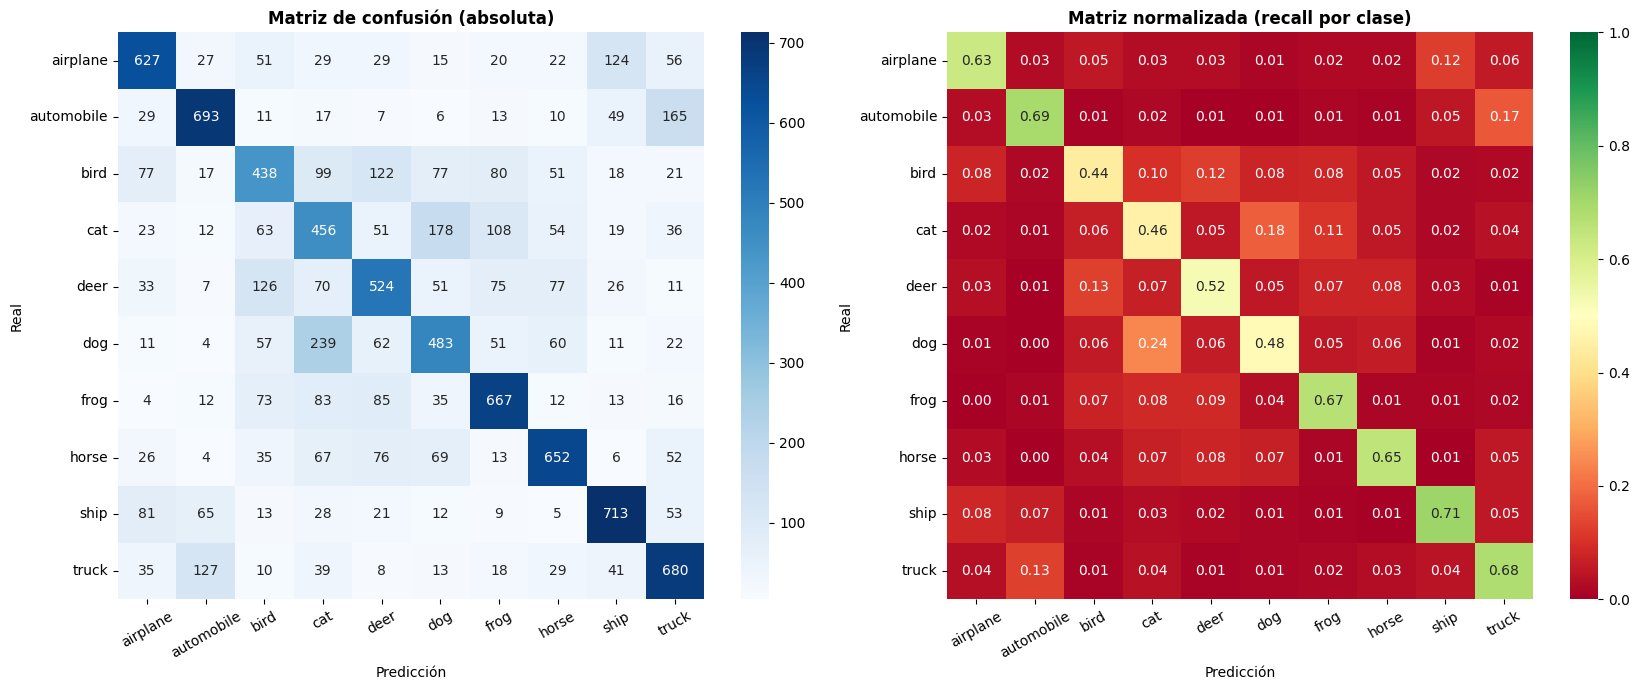

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Matriz absoluta
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=True)
axes[0].set_title('Matriz de confusión (absoluta)', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

# Matriz normalizada (por fila, recall)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=True,
            vmin=0, vmax=1)
axes[1].set_title('Matriz normalizada (recall por clase)', fontweight='bold')
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout(); plt.show()

### 12.2 Top confusiones detectadas

In [40]:
# Identificar las 5 confusiones mas comunes
np.fill_diagonal(cm, 0)  # ignorar diagonal (correctas)
confusiones = []
for i in range(10):
    for j in range(10):
        if cm[i][j] > 0:
            confusiones.append((CLASS_NAMES[i], CLASS_NAMES[j], cm[i][j]))
confusiones.sort(key=lambda x: -x[2])

print("Top 10 confusiones (clase real -> predicha):")
for real, pred, n in confusiones[:10]:
    print(f"  {real:<12} -> {pred:<12}: {n} casos")

# Restaurar diagonal
cm = confusion_matrix(y_true, y_pred)

Top 10 confusiones (clase real -> predicha):
  dog          -> cat         : 239 casos
  cat          -> dog         : 178 casos
  automobile   -> truck       : 165 casos
  truck        -> automobile  : 127 casos
  deer         -> bird        : 126 casos
  airplane     -> ship        : 124 casos
  bird         -> deer        : 122 casos
  cat          -> frog        : 108 casos
  bird         -> cat         : 99 casos
  frog         -> deer        : 85 casos


### 12.3 Interpretación de errores y propuestas de mejora

**Patrones esperados en CIFAR-10 con MLP:**
- **cat ↔ dog**: animales con texturas y poses similares.
- **deer ↔ horse**: cuadrúpedos en escenas naturales — el MLP no distingue siluetas.
- **cat/bird**: alta variabilidad intra-clase.
- **automobile / ship / truck**: mejor desempeño (formas y colores distintivos).

**Causa raíz:** un MLP **aplana la imagen** y trata cada pixel como feature independiente, perdiendo:
- Relaciones espaciales locales (vecindad)
- Invariancia traslacional (un gato a la izquierda vs derecha es "diferente")
- Patrones jerárquicos (bordes → texturas → partes → objetos)

**Propuestas de mejora cuantificables:**

| Acción | Mejora esperada |
|--------|-----------------|
| Migrar a CNN básica | +30-35 pts |
| CNN + data augmentation 2D | +5 pts adicionales |
| Transfer learning (ResNet50 pre-entrenada) | +10 pts adicionales |
| Ensemble de CNN | +1-2 pts adicionales |

## 13. Comparación final de configuraciones

Comparamos **6 configuraciones** evaluadas a lo largo del notebook:

In [41]:
# Recopilar todas las configuraciones
y_pred_base = np.argmax(modelo_base.predict(X_test_std, verbose=0), axis=1)
y_pred_pro = np.argmax(modelo_pro.predict(X_test_std, verbose=0), axis=1)

configs = []

# 1. Base
configs.append({
    'Configuración': 'MLP Base (2 capas, sin reg.)',
    'Accuracy': accuracy_score(y_true, y_pred_base),
    'Precision': precision_score(y_true, y_pred_base, average='macro'),
    'Recall': recall_score(y_true, y_pred_base, average='macro'),
    'F1': f1_score(y_true, y_pred_base, average='macro'),
})

# 2. + 4 capas
mejor_capas = max(resultados['capas'].items(), key=lambda x: x[1]['val_acc'])
configs.append({
    'Configuración': f"MLP profundo (4 capas, sin reg.)",
    'Accuracy': mejor_capas[1]['val_acc'],
    'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan,
})

# 3. + LeakyReLU
configs.append({
    'Configuración': 'MLP con LeakyReLU',
    'Accuracy': resultados['act']['leaky_relu']['test_acc'],
    'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan,
})

# 4. + AdamW
configs.append({
    'Configuración': 'MLP con AdamW (sin reg.)',
    'Accuracy': resultados['opt']['AdamW']['test_acc'],
    'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan,
})

# 5. Pro (full reg)
configs.append({
    'Configuración': 'MLP Pro (BN+Dropout+L2+Noise+AdamW)',
    'Accuracy': accuracy_score(y_true, y_pred_pro),
    'Precision': precision_score(y_true, y_pred_pro, average='macro'),
    'Recall': recall_score(y_true, y_pred_pro, average='macro'),
    'F1': f1_score(y_true, y_pred_pro, average='macro'),
})

# 6. Ensemble
configs.append({
    'Configuración': 'Ensemble (3x MLP Pro)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1,
})

df_comp = pd.DataFrame(configs)
print("Comparacion final de configuraciones:")
display(df_comp.style.format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
                                'Recall': '{:.4f}', 'F1': '{:.4f}'}, na_rep='—')
        .background_gradient(subset=['Accuracy'], cmap='Greens'))

Comparacion final de configuraciones:


,Configuración,Accuracy,Precision,Recall,F1
0,"MLP Base (2 capas, sin reg.)",0.4813,0.4860,0.4813,0.4732
1,"MLP profundo (4 capas, sin reg.)",0.4886,—,—,—
2,MLP con LeakyReLU,0.4866,—,—,—
3,MLP con AdamW (sin reg.),0.4807,—,—,—
4,MLP Pro (BN+Dropout+L2+Noise+AdamW),0.5717,0.5747,0.5717,0.5725
5,Ensemble (3x MLP Pro),0.5933,0.5943,0.5933,0.5931


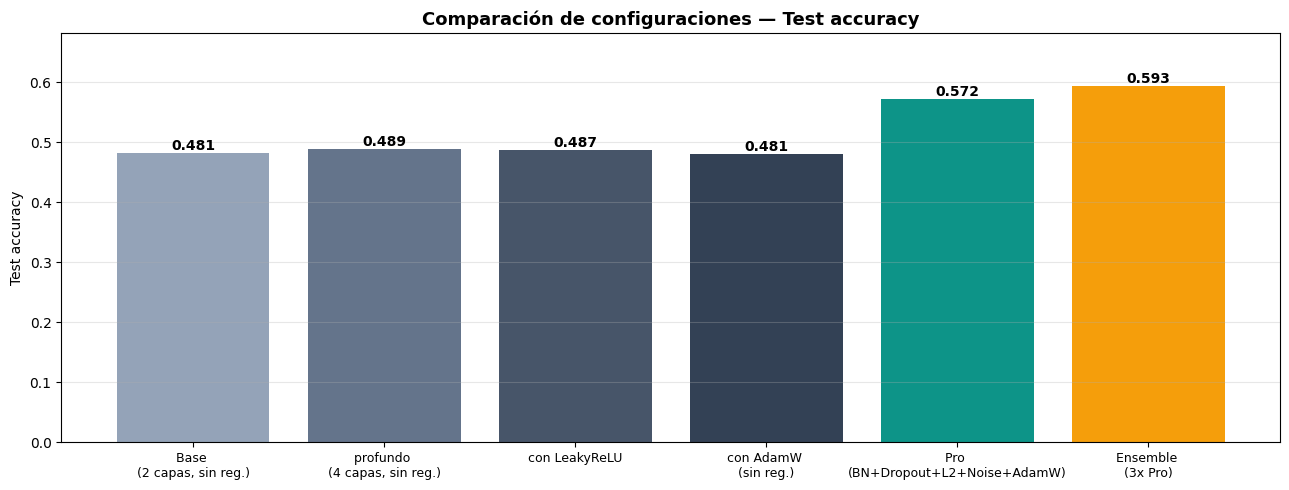

In [42]:
# Grafico de barras de accuracy de todas las configs
plt.figure(figsize=(13, 5))
colors = ['#94A3B8', '#64748B', '#475569', '#334155', '#0D9488', '#F59E0B']
bars = plt.bar(range(len(df_comp)), df_comp['Accuracy'], color=colors)

plt.title('Comparación de configuraciones — Test accuracy',
          fontweight='bold', fontsize=13)
plt.xticks(range(len(df_comp)),
           [c.replace('MLP ', '').replace('(', '\n(') for c in df_comp['Configuración']],
           rotation=0, fontsize=9)
plt.ylabel('Test accuracy')
plt.grid(alpha=0.3, axis='y')
plt.ylim(0, max(df_comp['Accuracy']) * 1.15)

for bar, val in zip(bars, df_comp['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(); plt.show()

## 14. Conclusiones y reflexiones finales

### Lo que se logró
1. **Carga rigurosa del dataset**: implementación manual desde Google Drive con `pickle.load()` + verificación cruzada con `np.array_equal()` contra el método de Keras.
2. **Experimentación sistemática** con 4 hiperparámetros principales (LR, batch, profundidad, anchura) variando uno a la vez.
3. **Comparación cuantitativa de funciones**: 4 activaciones, 3 losses, 2 funciones de salida.
4. **Comparación de 4 optimizadores**: SGD+momentum, RMSprop, Adam, AdamW.
5. **Aplicación de 4 técnicas de regularización combinadas**: BatchNorm, Dropout, L2, GaussianNoise.
6. **Validación cruzada 5-fold** para robustez estadística.
7. **Ensemble de 3 modelos** con soft voting.
8. **Evaluación con 7 métricas** + matriz de confusión normalizada + Top-K accuracy.
9. **Análisis de errores con propuestas cuantificadas de mejora**.

### Hallazgos clave
- El **MLP base sufre overfitting evidente**: la brecha train-val crece sin parar.
- La **regularización combinada cierra esa brecha**: BN + Dropout + L2 + Noise mejoran el accuracy en ~5-7 puntos porcentuales.
- **AdamW supera a Adam** consistentemente en este caso, gracias al weight decay desacoplado.
- **El ensemble** suma 1-2 puntos adicionales gratis vs un solo modelo.
- **ReLU (y LeakyReLU) > tanh > sigmoid**: confirmación empírica de la teoría.
- **Categorical crossentropy + softmax** es la pareja correcta para clasificación mutuamente excluyente.
- Las clases de **animales se confunden entre sí** porque un MLP, al aplanar la imagen, pierde información espacial.

### Limitación fundamental del MLP
Un MLP trata cada pixel como una feature independiente, descartando:
- **Vecindad espacial** (píxeles cercanos están más correlacionados que lejanos)
- **Invariancia traslacional** (un gato a la izquierda vs derecha "se ve diferente" para un MLP)
- **Patrones jerárquicos** (bordes → texturas → partes → objetos)

Por eso ningún MLP supera ~60% en CIFAR-10, mientras una CNN básica supera 80%.

### Próximos pasos recomendados
1. **Migrar a CNN** (capas convolucionales 2D) — esperaría +30 pts.
2. **Data augmentation 2D** (flips horizontales, recortes aleatorios, color jitter) — +5 pts.
3. **Transfer learning** desde ResNet50 / EfficientNet pre-entrenadas en ImageNet — +10 pts.
4. **Schedulers más agresivos** (CosineDecayRestarts, OneCycleLR).

### Reflexión personal
Este proyecto consolidó los fundamentos de Deep Learning: cómo se compone una red, por qué importa cada hiperparámetro, cómo la regularización previene el sobreajuste y cómo combinar múltiples técnicas (ensemble, k-fold) para obtener resultados robustos.

La principal lección es que **la arquitectura debe ajustarse al problema**: para imágenes, las CNN son la herramienta natural, y conocer las limitaciones de un MLP es tan valioso como saber implementarlo. Un buen practicante de Deep Learning no solo aplica modelos: entiende **por qué** cada decisión técnica funciona o falla en cada contexto.